# Day 09. Exercise 00
# Regularization

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import joblib

## 1. Preprocessing

1. Read the file `dayofweek.csv` that you used in the previous day to a dataframe.
2. Using `train_test_split` with parameters `test_size=0.2`, `random_state=21` get `X_train`, `y_train`, `X_test`, `y_test`. Use the additional parameter `stratify`.

In [2]:
df=pd.read_csv('../data/dayofweek.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1686 entries, 0 to 1685
Data columns (total 44 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   dayOfWeek         1686 non-null   int64  
 1   hour              1686 non-null   float64
 2   numTrials         1686 non-null   float64
 3   uid_user_0        1686 non-null   float64
 4   uid_user_1        1686 non-null   float64
 5   uid_user_10       1686 non-null   float64
 6   uid_user_11       1686 non-null   float64
 7   uid_user_12       1686 non-null   float64
 8   uid_user_13       1686 non-null   float64
 9   uid_user_14       1686 non-null   float64
 10  uid_user_15       1686 non-null   float64
 11  uid_user_16       1686 non-null   float64
 12  uid_user_17       1686 non-null   float64
 13  uid_user_18       1686 non-null   float64
 14  uid_user_19       1686 non-null   float64
 15  uid_user_2        1686 non-null   float64
 16  uid_user_20       1686 non-null   float64


In [3]:
X=df.drop(columns='dayOfWeek')
y=df['dayOfWeek']

X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=21, stratify=y)

## 2. Logreg regularization

### a. Default regularization

1. Train a baseline model with the only parameters `random_state=21`, `fit_intercept=False`.
2. Use stratified K-fold cross-validation with `10` splits to evaluate the accuracy of the model


The result of the code where you trained and evaluated the baseline model should be exactly like this (use `%%time` to get the info about how long it took to run the cell):

```
train -  0.62902   |   valid -  0.59259
train -  0.64633   |   valid -  0.62963
train -  0.63479   |   valid -  0.56296
train -  0.65622   |   valid -  0.61481
train -  0.63397   |   valid -  0.57778
train -  0.64056   |   valid -  0.59259
train -  0.64138   |   valid -  0.65926
train -  0.65952   |   valid -  0.56296
train -  0.64333   |   valid -  0.59701
train -  0.63674   |   valid -  0.62687
Average accuracy on crossval is 0.60165
Std is 0.02943
```

In [4]:
lr = LogisticRegression(random_state=21, fit_intercept=False)

In [5]:
def crossval(model, X, y, n_splits=10):
    train_scores = []
    valid_scores = []
    skf = StratifiedKFold(n_splits=10)
    for train, valid in skf.split(X, y):
        X_train, X_valid = X.iloc[train], X.iloc[valid]
        y_train, y_valid = y.iloc[train], y.iloc[valid]
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_valid_pred = model.predict(X_valid)
        train_scores.append(accuracy_score(y_train, y_train_pred))
        valid_scores.append(accuracy_score(y_valid, y_valid_pred))
        
    for i in range(len(train_scores)):
        print(f'train - {train_scores[i]:.5f} | valid - {valid_scores[i]:.5f}')
        
    print(f'Average accuracy on crossval is {np.mean(valid_scores):.5f}')
    print(f'Std is {np.std(valid_scores):.5f}')

In [6]:
%%time
crossval(lr, X_train, y_train)

train - 0.62902 | valid - 0.59259
train - 0.64633 | valid - 0.62963
train - 0.63479 | valid - 0.56296
train - 0.65622 | valid - 0.61481
train - 0.63397 | valid - 0.57778
train - 0.64056 | valid - 0.59259
train - 0.64138 | valid - 0.65926
train - 0.65952 | valid - 0.56296
train - 0.64333 | valid - 0.59701
train - 0.63674 | valid - 0.62687
Average accuracy on crossval is 0.60165
Std is 0.02943
CPU times: user 2.16 s, sys: 4.32 s, total: 6.48 s
Wall time: 419 ms


### b. Optimizing regularization parameters

1. In the cells below try different values of penalty: `none`, `l1`, `l2` – you can change the values of solver too.

In [7]:
%%time
lr_none = LogisticRegression(penalty='none', fit_intercept=False, random_state=21,max_iter=1000)
crossval(lr_none, X_train, y_train)

train - 0.66694 | valid - 0.63704
train - 0.65787 | valid - 0.65926
train - 0.66694 | valid - 0.57778
train - 0.66529 | valid - 0.62963
train - 0.66694 | valid - 0.62222
train - 0.65952 | valid - 0.57778
train - 0.64963 | valid - 0.69630
train - 0.68425 | valid - 0.61481
train - 0.66474 | valid - 0.62687
train - 0.65651 | valid - 0.60448
Average accuracy on crossval is 0.62462
Std is 0.03379
CPU times: user 8.69 s, sys: 16.3 s, total: 25 s
Wall time: 1.61 s


In [8]:
%%time
lr_none = LogisticRegression(penalty='none', solver='saga',fit_intercept=False, random_state=21,max_iter=5000)
crossval(lr_none, X_train, y_train)

train - 0.66612 | valid - 0.63704
train - 0.65787 | valid - 0.65926
train - 0.66612 | valid - 0.57778
train - 0.66529 | valid - 0.62963
train - 0.66694 | valid - 0.62222
train - 0.65952 | valid - 0.57778
train - 0.65045 | valid - 0.69630
train - 0.68425 | valid - 0.61481
train - 0.66474 | valid - 0.62687
train - 0.65651 | valid - 0.60448
Average accuracy on crossval is 0.62462
Std is 0.03379
CPU times: user 22 s, sys: 12.8 s, total: 34.9 s
Wall time: 17.7 s


In [10]:
%%time
lr_none = LogisticRegression(penalty='none', solver='newton-cg',fit_intercept=False, random_state=21,max_iter=1000)
crossval(lr_none, X_train, y_train)

train - 0.66694 | valid - 0.63704
train - 0.65787 | valid - 0.65926
train - 0.66694 | valid - 0.57778
train - 0.66529 | valid - 0.62963
train - 0.66694 | valid - 0.62222
train - 0.65952 | valid - 0.57778
train - 0.65045 | valid - 0.69630
train - 0.68425 | valid - 0.61481
train - 0.66474 | valid - 0.62687
train - 0.65651 | valid - 0.60448
Average accuracy on crossval is 0.62462
Std is 0.03379
CPU times: user 11.3 s, sys: 16.4 s, total: 27.7 s
Wall time: 1.76 s


In [11]:
%%time
lr_l2 = LogisticRegression(penalty='l2', fit_intercept=False, random_state=21, max_iter=1000)
crossval(lr_l2, X_train, y_train)

train - 0.62902 | valid - 0.59259
train - 0.64633 | valid - 0.62963
train - 0.63479 | valid - 0.56296
train - 0.65622 | valid - 0.61481
train - 0.63397 | valid - 0.57778
train - 0.64056 | valid - 0.59259
train - 0.64138 | valid - 0.65926
train - 0.65952 | valid - 0.56296
train - 0.64333 | valid - 0.59701
train - 0.63674 | valid - 0.62687
Average accuracy on crossval is 0.60165
Std is 0.02943
CPU times: user 2.02 s, sys: 4.05 s, total: 6.07 s
Wall time: 396 ms


In [12]:
%%time
lr_l2 = LogisticRegression(penalty='l2',solver='liblinear', fit_intercept=False, random_state=21, max_iter=1000)
crossval(lr_l2, X_train, y_train)

train - 0.61006 | valid - 0.56296
train - 0.61665 | valid - 0.61481
train - 0.61336 | valid - 0.59259
train - 0.62902 | valid - 0.60741
train - 0.60923 | valid - 0.55556
train - 0.61500 | valid - 0.57778
train - 0.61665 | valid - 0.61481
train - 0.64056 | valid - 0.53333
train - 0.62109 | valid - 0.58209
train - 0.61120 | valid - 0.57463
Average accuracy on crossval is 0.58160
Std is 0.02532
CPU times: user 510 ms, sys: 1.04 s, total: 1.55 s
Wall time: 113 ms


In [13]:
%%time
lr_l2 = LogisticRegression(penalty='l2',solver='saga', fit_intercept=False, random_state=21, max_iter=5000)
crossval(lr_l2, X_train, y_train)

train - 0.62902 | valid - 0.59259
train - 0.64633 | valid - 0.62963
train - 0.63479 | valid - 0.56296
train - 0.65622 | valid - 0.61481
train - 0.63397 | valid - 0.57778
train - 0.64056 | valid - 0.59259
train - 0.64221 | valid - 0.65926
train - 0.65952 | valid - 0.56296
train - 0.64333 | valid - 0.59701
train - 0.63674 | valid - 0.62687
Average accuracy on crossval is 0.60165
Std is 0.02943
CPU times: user 4.77 s, sys: 10.8 s, total: 15.6 s
Wall time: 1.03 s


In [14]:
%%time
lr_l2 = LogisticRegression(penalty='l2',solver='newton-cg', fit_intercept=False, random_state=21, max_iter=1000)
crossval(lr_l2, X_train, y_train)

train - 0.62902 | valid - 0.59259
train - 0.64633 | valid - 0.62963
train - 0.63479 | valid - 0.56296
train - 0.65622 | valid - 0.61481
train - 0.63397 | valid - 0.57778
train - 0.64056 | valid - 0.59259
train - 0.64221 | valid - 0.65926
train - 0.65952 | valid - 0.56296
train - 0.64333 | valid - 0.59701
train - 0.63674 | valid - 0.62687
Average accuracy on crossval is 0.60165
Std is 0.02943
CPU times: user 2.65 s, sys: 4.91 s, total: 7.56 s
Wall time: 482 ms


In [15]:
%%time
lr_l1 = LogisticRegression(penalty='l1',solver='liblinear', fit_intercept=False, random_state=21, max_iter=1000)
crossval(lr_l1, X_train, y_train)

train - 0.61830 | valid - 0.54815
train - 0.62737 | valid - 0.62222
train - 0.60511 | valid - 0.54074
train - 0.63644 | valid - 0.62222
train - 0.62407 | valid - 0.55556
train - 0.62325 | valid - 0.58519
train - 0.61253 | valid - 0.63704
train - 0.64716 | valid - 0.58519
train - 0.63015 | valid - 0.59701
train - 0.61367 | valid - 0.59701
Average accuracy on crossval is 0.58903
Std is 0.03129
CPU times: user 717 ms, sys: 1.72 s, total: 2.43 s
Wall time: 173 ms


## 3. SVM regularization

### a. Default regularization

1. Train a baseline model with the only parameters `probability=True`, `kernel='linear'`, `random_state=21`.
2. Use stratified K-fold cross-validation with `10` splits to evaluate the accuracy of the model.
3. The format of the result of the code where you trained and evaluated the baseline model should be similar to what you have got for the logreg.

In [17]:
svm = SVC(random_state=21, probability=True, kernel='linear')

In [18]:
%%time
crossval(svm, X_train, y_train)

train - 0.70486 | valid - 0.65926
train - 0.69662 | valid - 0.75556
train - 0.69415 | valid - 0.62222
train - 0.70239 | valid - 0.65185
train - 0.69085 | valid - 0.65185
train - 0.68920 | valid - 0.64444
train - 0.69250 | valid - 0.72593
train - 0.70074 | valid - 0.62222
train - 0.69605 | valid - 0.61940
train - 0.71087 | valid - 0.63433
Average accuracy on crossval is 0.65871
Std is 0.04359
CPU times: user 1.87 s, sys: 1.59 ms, total: 1.87 s
Wall time: 1.87 s


### b. Optimizing regularization parameters

1. In the cells below try different values of the parameter `C`.

In [19]:
%%time
svm = SVC(random_state=21, probability=True, kernel='linear', C=1)
crossval(svm, X_train, y_train)

train - 0.70486 | valid - 0.65926
train - 0.69662 | valid - 0.75556
train - 0.69415 | valid - 0.62222
train - 0.70239 | valid - 0.65185
train - 0.69085 | valid - 0.65185
train - 0.68920 | valid - 0.64444
train - 0.69250 | valid - 0.72593
train - 0.70074 | valid - 0.62222
train - 0.69605 | valid - 0.61940
train - 0.71087 | valid - 0.63433
Average accuracy on crossval is 0.65871
Std is 0.04359
CPU times: user 1.84 s, sys: 532 µs, total: 1.84 s
Wall time: 1.84 s


In [20]:
%%time
svm = SVC(random_state=21, probability=True, kernel='linear', C=2)
crossval(svm, X_train, y_train)

train - 0.70734 | valid - 0.65926
train - 0.71393 | valid - 0.75556
train - 0.74526 | valid - 0.63704
train - 0.71558 | valid - 0.66667
train - 0.71146 | valid - 0.67407
train - 0.70157 | valid - 0.63704
train - 0.70651 | valid - 0.71852
train - 0.70981 | valid - 0.64444
train - 0.72405 | valid - 0.64925
train - 0.72488 | valid - 0.64179
Average accuracy on crossval is 0.66836
Std is 0.03721
CPU times: user 1.93 s, sys: 0 ns, total: 1.93 s
Wall time: 1.93 s


In [21]:
%%time
svm = SVC(random_state=21, probability=True, kernel='linear', C=4)
crossval(svm, X_train, y_train)

train - 0.71723 | valid - 0.65185
train - 0.75598 | valid - 0.82222
train - 0.77741 | valid - 0.67407
train - 0.73619 | valid - 0.66667
train - 0.72218 | valid - 0.71111
train - 0.72960 | valid - 0.69630
train - 0.72383 | valid - 0.71852
train - 0.74444 | valid - 0.63704
train - 0.75371 | valid - 0.67164
train - 0.75700 | valid - 0.68657
Average accuracy on crossval is 0.69360
Std is 0.04905
CPU times: user 2.13 s, sys: 961 µs, total: 2.13 s
Wall time: 2.13 s


## 4. Tree

### a. Default regularization

1. Train a baseline model with the only parameter `max_depth=10` and `random_state=21`.
2. Use stratified K-fold cross-validation with `10` splits to evaluate the accuracy of the model.
3. The format of the result of the code where you trained and evaluated the baseline model should be similar to what you have got for the logreg.

In [25]:
%%time
tree = DecisionTreeClassifier(random_state=21, max_depth=10)
crossval(tree, X_train, y_train)

train - 0.81039 | valid - 0.74815
train - 0.77741 | valid - 0.74815
train - 0.83347 | valid - 0.71111
train - 0.79720 | valid - 0.76296
train - 0.82440 | valid - 0.76296
train - 0.80379 | valid - 0.68889
train - 0.80709 | valid - 0.76296
train - 0.80132 | valid - 0.65926
train - 0.80807 | valid - 0.75373
train - 0.80478 | valid - 0.68657
Average accuracy on crossval is 0.72847
Std is 0.03660
CPU times: user 52.5 ms, sys: 280 µs, total: 52.8 ms
Wall time: 52.6 ms


### b. Optimizing regularization parameters

1. In the cells below try different values of the parameter `max_depth`.
2. As a bonus, play with other regularization parameters trying to find the best combination.

In [29]:
params = {
    'criterion': ['gini', 'entropy'],
    "max_depth": range(10, 40),
    'min_samples_split': range(2, 4),
    'min_samples_leaf': range(1, 4),
}

tree = DecisionTreeClassifier(random_state=21)

gs = GridSearchCV(
    estimator=tree,
    param_grid=params,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

gs.fit(X_train, y_train)
print(f'Best params: {gs.best_params_}')
print(f'Best score: {gs.best_score_}')

Best params: {'criterion': 'gini', 'max_depth': 22, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best score: 0.8716343108908164


In [30]:
%%time
tree = DecisionTreeClassifier(random_state=21, max_depth=22, min_samples_split=2, min_samples_leaf=1)
crossval(tree, X_train, y_train)

train - 0.99423 | valid - 0.86667
train - 0.99340 | valid - 0.88889
train - 0.99423 | valid - 0.86667
train - 0.99588 | valid - 0.89630
train - 0.99423 | valid - 0.88148
train - 0.99093 | valid - 0.86667
train - 0.99176 | valid - 0.91852
train - 0.99588 | valid - 0.88889
train - 0.99753 | valid - 0.88060
train - 0.99176 | valid - 0.88060
Average accuracy on crossval is 0.88353
Std is 0.01523
CPU times: user 48.9 ms, sys: 2.15 ms, total: 51.1 ms
Wall time: 50.6 ms


## 5. Random forest

### a. Default regularization

1. Train a baseline model with the only parameters `n_estimators=50`, `max_depth=14`, `random_state=21`.
2. Use stratified K-fold cross-validation with `10` splits to evaluate the accuracy of the model.
3. The format of the result of the code where you trained and evaluated the baseline model should be similar to what you have got for the logreg.

In [31]:
%%time
forest = RandomForestClassifier(random_state=21, n_estimators=50, max_depth=14)
crossval(forest, X_train, y_train)

train - 0.96208 | valid - 0.85185
train - 0.96043 | valid - 0.91111
train - 0.96785 | valid - 0.89630
train - 0.97115 | valid - 0.89630
train - 0.96455 | valid - 0.90370
train - 0.96620 | valid - 0.84444
train - 0.96373 | valid - 0.89630
train - 0.96290 | valid - 0.82963
train - 0.97117 | valid - 0.87313
train - 0.97446 | valid - 0.86567
Average accuracy on crossval is 0.87684
Std is 0.02660
CPU times: user 510 ms, sys: 4.04 ms, total: 514 ms
Wall time: 513 ms


### b. Optimizing regularization parameters

1. In the new cells try different values of the parameters `max_depth` and `n_estimators`.
2. As a bonus, play with other regularization parameters trying to find the best combination.

In [32]:
params = {
    'n_estimators': range(100, 250, 30),
    'max_depth': range(20, 40, 5),
    'min_samples_split': range(2, 4),
    'min_samples_leaf': range(1, 4),
}
gs = GridSearchCV(estimator=RandomForestClassifier(random_state=21), param_grid=params, scoring='accuracy', cv=5, n_jobs=-1)
gs.fit(X_train, y_train)
print(f'Best params: {gs.best_params_}')
print(f'Best score: {gs.best_score_}')

Best params: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 160}
Best score: 0.9013355362797743


In [33]:
%%time
forest = RandomForestClassifier(random_state=21, n_estimators=160, max_depth=30)
crossval(forest, X_train, y_train)

train - 1.00000 | valid - 0.90370
train - 1.00000 | valid - 0.94815
train - 1.00000 | valid - 0.90370
train - 1.00000 | valid - 0.91852
train - 1.00000 | valid - 0.92593
train - 1.00000 | valid - 0.89630
train - 1.00000 | valid - 0.92593
train - 1.00000 | valid - 0.90370
train - 1.00000 | valid - 0.91791
train - 1.00000 | valid - 0.90299
Average accuracy on crossval is 0.91468
Std is 0.01495
CPU times: user 1.73 s, sys: 6.65 ms, total: 1.74 s
Wall time: 1.73 s


## 6. Predictions

1. Choose the best model and use it to make predictions for the test dataset.
2. Calculate the final accuracy.
3. Analyze: for which weekday your model makes the most errors (in % of the total number of samples of that class in your test dataset).
4. Save the model.

In [34]:
forest = RandomForestClassifier(random_state=21, n_estimators=160, max_depth=30)
forest.fit(X_train, y_train)
y_pred = forest.predict(X_test)
accuracy_score(y_test, y_pred)

0.9319526627218935

In [35]:
report = classification_report(y_test, y_pred, labels=range(0, 7))
print(report)

              precision    recall  f1-score   support

           0       0.91      0.74      0.82        27
           1       0.98      0.93      0.95        55
           2       0.97      0.93      0.95        30
           3       0.95      0.97      0.96        80
           4       1.00      0.86      0.92        21
           5       0.89      0.93      0.91        54
           6       0.89      0.99      0.93        71

    accuracy                           0.93       338
   macro avg       0.94      0.91      0.92       338
weighted avg       0.93      0.93      0.93       338



In [36]:
matrix = confusion_matrix(y_test, y_pred)
matrix

array([[20,  1,  0,  0,  0,  1,  5],
       [ 1, 51,  1,  0,  0,  1,  1],
       [ 0,  0, 28,  2,  0,  0,  0],
       [ 1,  0,  0, 78,  0,  0,  1],
       [ 0,  0,  0,  0, 18,  3,  0],
       [ 0,  0,  0,  2,  0, 50,  2],
       [ 0,  0,  0,  0,  0,  1, 70]])

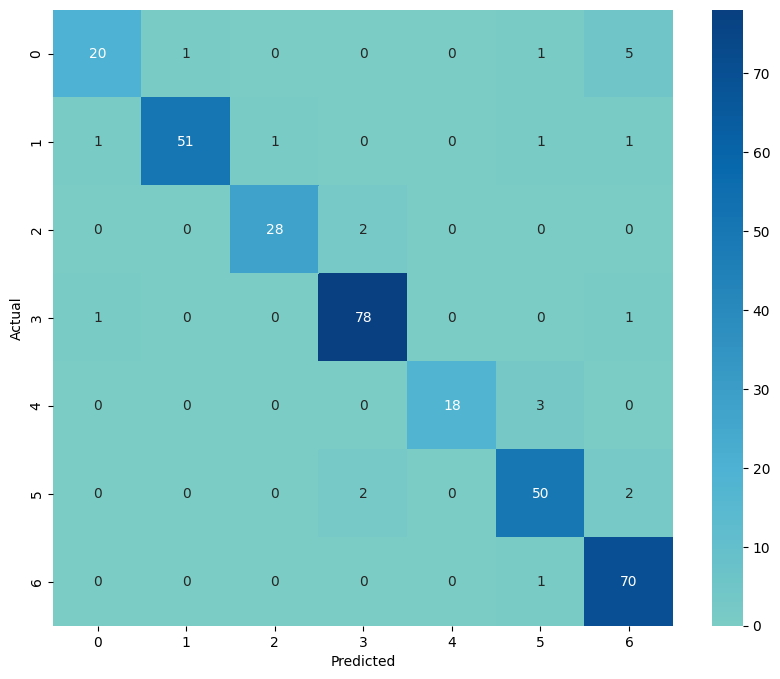

In [37]:
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, cmap="GnBu", center=0, cbar=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [38]:
joblib.dump(forest, '../data/model_ex00.pkl')

['../data/model_ex00.pkl']